# **ConvNeXt-Tiny Lightweight Fine-Tuning**
*Created and runned with Google Colab*

This code has to be executed AFTER the other notebook (numbered as 01), follow the numeration. \
**Dataset**: *Rare Neurological Diseases MRI - curated ver*, from [Kaggle](https://www.kaggle.com/datasets/ahsanneural/rare-neurological-diseases-mri-curated-edition)

> This dataset is derived from the *"Benchmark Diagnostic MRI and Medical Imaging Dataset"* published on Mendeley Data by *Haseeb Hassan, M. Usman Akram, Waqas Ahmad, and Sajid Gul Khawaja (2024)*, available at this link [Mendeley Data](https://data.mendeley.com/datasets/d73rs38yk6/1)

**Strategy 2 of the comparison: transfer learning** \
The ImageNet ConvNeXt-Tiny is frozen except for its last stage, the classification head is replaced with a 5-class linear layer, and the network is trained end-to-end on the MRI images \
No separate classifier: the network predicts directly.

Same dataset, same splits, same seed as *notebook 01*, so the two strategies are directly comparable.


## **1) Drive mount & Kaggle dataset's download**


In order to correctly configure the project, in your drive there must be the folder for the project, in my case is inside the folder I use for my University projects.
Plus, to download the dataset directly from Kaggle (to have the last version), it is required to copy an info from your Kaggle's account as follows:
- Go to [Kaggle' site](https://www.kaggle.com/) and log in it
- By intercat with your profile photo on the top-right, go to `Settings`
- Search for the section `API` and `Generate New Token`, it will open a pop up with some info:
  - **API TOKEN** (`KGAT_...`): This is your unique password. Copy it now, because Kaggle will never show it to you again

  - **Option 1** (`export KAGGLE_API_TOKEN=...`): It is used to save the token as a temporary environment variable in the terminal Linux/Mac.

  - **Option 2** (`mkdir -p ~/.kaggle && echo ...`): It is a terminal command that automatically creates the `~/.kaggle folder`, saves the token inside it in a file named `access_token`, and assigns the correct security permissions

  - **Final command** (kaggle competitions list): Example command to check if the token works.
- Copy the **API TOKEN** and return to Colab
- Open the menu on the left and intercat with the **key icon**
- Then add a **new secret**
  - **Name:** *KAGGLE_API_TOKEN*
  - **Value:** paste here the **API TOKEN**
- Finally, active the switch *"Notebook access"*


> If you don't want to use the key, you can **modify the code** when the key is required by pasting the API token in the else branch (section 2 of the following code)


By following those steps, you will be able to download the dataset directly from the Kaggle's site.


This cell is the only one that talks to the outside world. It does five things:
1. **Mounts Google Drive** so that data/features/models survive a runtime reset
2. **Reads the Kaggle token** from Colab Secrets (never hard-code it in a repo)
3. **Creates** the project folder tree on Drive
  > note `MODEL_DIR` and `UTILS_DIR` point at *convnext* folders here, so nothing overwrites the ResNet artifacts from notebook 01
4. **Clones** the source repo and puts it on `sys.path`
5. **Checks** whether the dataset is already on Drive, and downloads it only if the folder is empty

Everything downstream assumes the paths defined here.


In [1]:
import os
from pathlib import Path
from google.colab import drive, userdata
import sys

# 1. Google Drive mount
# drive.mount() attaches the user's Drive under /content/drive
drive.mount('/content/drive')


# 2. Kaggle API configuration - AFTER adding the secret
# userdata.get() reads a secret stored in the Colab key panel
try:
    os.environ["KAGGLE_API_TOKEN"] = userdata.get("KAGGLE_API_TOKEN")
except Exception:
    # If you don't use Colab's Secret, you can directly paste your token here
    os.environ["KAGGLE_API_TOKEN"] = "KGAT_..."


# 3. Path configuration
# pathlib.Path is used instead of raw strings so that the "/" operator builds paths safely and the same code stays OS-independent
BASE_DIR = Path('/content/drive/MyDrive/University/rare-neuro-mri')
DATA_DIR = BASE_DIR / "data"                       # where to save dataset
MODEL_DIR = BASE_DIR / "convnext models"           # where to save the model
UTILS_DIR = BASE_DIR / "convnext utils"            # where to save useful files created during the analysis

# Create the base folder and the 'data' subfolder if they do not already exist
# parents=True  -> also create missing intermediate folders
# exist_ok=True -> do not raise if the folder is already there (idempotent cell)
for d in [DATA_DIR, MODEL_DIR, UTILS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 4. Clone GitHub repo & add src folder to the project
REPO_URL = "https://github.com/Rayoyo/rare-neuro-mri.git"
REPO_DIR = Path("/content/rare-neuro-mri")

if not REPO_DIR.exists():
    !git clone {REPO_URL} {REPO_DIR}
print("Repo cloned!")

# repo added to importable moduls
if str(REPO_DIR) not in sys.path:
    sys.path.append(str(REPO_DIR))


# 5. Download verification and execution
# The "slug" is the <owner>/<dataset-name> identifier shown in the Kaggle URL
DATASET_SLUG = "ahsanneural/rare-neurological-diseases-mri-curated-edition"    #can be seen on Kaggle too when you want to download the file

# If the data folder is not empty, skip the download
if any(DATA_DIR.iterdir()):
    print(f" Dataset already present in: {DATA_DIR}")
    print("Folder contents:")
    for item in DATA_DIR.iterdir():
        print(f" - {item.name}")
else:
    print(f" Empty folder. Downloading the dataset '{DATASET_SLUG}'...")

    # Ensure that the Kaggle library is installed
    !pip install -q kaggle

    # Download and extract the data directly into the data folder on Drive
    !kaggle datasets download -d {DATASET_SLUG} -p "{DATA_DIR}" --unzip

    print(f"\n Download and extraction completed successfully!")
    print(f"The files are located in: {DATA_DIR}")


Mounted at /content/drive
Cloning into '/content/rare-neuro-mri'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 175 (delta 5), reused 10 (delta 1), pack-reused 154 (from 1)
Receiving objects: 100% (175/175), 31.50 MiB | 11.58 MiB/s, done.
Resolving deltas: 100% (70/70), done.
Repo cloned!
 Dataset already present in: /content/drive/MyDrive/University/rare-neuro-mri/data
Folder contents:
 - rare_neuro_mri_curated


## **2) Install dependencies**

Dependencies come from the repo's `requirements.txt`, so the notebook is reproducible across runtimes.

- **Preferred path:** install the pinned stack from `requirements.txt`
- **Fallback path:** if the repo is unavailable, install the minimum needed to run the notebook.

> Note: `-q` keeps `pip` quiet. After installing packages Colab has already imported (e.g.
> numpy/torch), a runtime restart may be required


In [2]:
# ---------------------------------------------------------
# Install dependencies
# ---------------------------------------------------------

requirements_file = REPO_DIR / "requirements.txt"
if requirements_file.exists():
    !pip install -q -r {requirements_file}
else:
    !pip install -q scikit-learn matplotlib seaborn tqdm torchio SimpleITK


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.6/203.6 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.4 MB/s eta 0:00:00


In [3]:
# Core imports: deep-learning backend, data handling, plotting, image I/O
import torch
import torch.nn as nn
import sys
import pandas as pd
import os
import matplotlib.pyplot as plt
import random
from PIL import Image
from torch.utils.data import DataLoader

In [4]:
# Numeric / metric helpers used below
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, f1_score

In [ ]:
# ---------------------------------------------------------
# Reproducibility & Device Setup
# ---------------------------------------------------------

In [5]:
# The modules live in <repo>/src as top-level modules, so src/ must be on sys.path
src_dir_path = REPO_DIR / "src"
if str(src_dir_path) not in sys.path:
    sys.path.insert(0, str(src_dir_path))

from dataset import (set_dataset_root, build_dataloaders, build_fewshot_train_dataset,
                     visualize_augmentations, set_seed, verify_dataset_structure)
from transfer_learning import (get_convnext_tiny_model, train_one_epoch, validate_epoch,
                               count_trainable_parameters, run_true_fewshot_finetuning)
from metrics import evaluate_and_save_all


In [6]:
# Select GPU if available, CPU if not
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

Device: cuda


> *Note*: In the output above, it is indicate that the last execution was done on **CPU**, not ideal for this work. \
>   In fact was used to perform lastes tests on the notebook

## **3) Dataset structure & exploration**

The same three checks as *notebook 01*, repeated because this notebook runs as a standalone session:
the folder tree, `verify_dataset_structure()` for the class counts and the canonical label order, and
a sample grid for a qualitative look at the images.


In [7]:
# ---------------------------------------------------------
# Data Structure Overview
# ---------------------------------------------------------

DATASET_ROOT = DATA_DIR / "rare_neuro_mri_curated"

# os.walk() yields (current_dir, subdirs, files) recursively, top-down
for root, dirs, files in os.walk(DATASET_ROOT):
  # Depth is inferred by counting the path separators left after stripping
  # the root prefix -> used to indent the printed tree
    level = root.replace(str(DATASET_ROOT), '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 2 * (level + 1)
    if level < 3 and files:
        for f in files[:3]:
            print(f'{subindent}{f} ...')
        if len(files) > 3:
            print(f'{subindent}... and {len(files)-3} more files')

rare_neuro_mri_curated/
  disease_summary.csv ...
  metadata.csv ...
  test/
    fukuyama_muscular_dystrophy/
      fukuyama_muscular_dystrophy_test_0000.jpg ...
      fukuyama_muscular_dystrophy_test_0001.jpg ...
      fukuyama_muscular_dystrophy_test_0002.jpg ...
      ... and 57 more files
    hallervorden_spatz_disease/
      hallervorden_spatz_disease_test_0000.jpg ...
      hallervorden_spatz_disease_test_0001.jpg ...
      hallervorden_spatz_disease_test_0002.jpg ...
      ... and 57 more files
    moyamoya_disease/
      moyamoya_disease_test_0000.jpg ...
      moyamoya_disease_test_0001.jpg ...
      moyamoya_disease_test_0002.jpg ...
      ... and 57 more files
    pachygyria_cerebellar_hypoplasia/
      pachygyria_cerebellar_hypoplasia_test_0000.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0001.jpg ...
      pachygyria_cerebellar_hypoplasia_test_0002.jpg ...
      ... and 57 more files
    walker_warburg_syndrome/
      walker_warburg_syndrome_test_0000.jpg ...
      

In [8]:
# ---------------------------------------------------------
# Split verification & Class Distribution
# ---------------------------------------------------------
'''Same invariant as notebook 01: the Kaggle archive already ships the 70/15/15 split by
class, no re-splitting needed, but every split must expose the SAME class folders
MRIDataset assigns labels via sorted(folder_names) independently per split, so a class
missing from one split would shift every subsequent label and the model would train against permuted targets
verify_dataset_structure() raises immediately if that happens'''

disease_classes, split_counts = verify_dataset_structure(DATASET_ROOT)

df_stats = pd.DataFrame(split_counts).fillna(0).astype(int)
print("\nDataset Statistics:")
print(df_stats)
print(f"Total images: {df_stats.sum().sum()}")
print(f"Canonical class order: {disease_classes}")


Dataset structure verified: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated
  Canonical class order (label 0..4): ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']
  train ->  1400 images | per-class: [280]
  val   ->   300 images | per-class: [60]
  test  ->   300 images | per-class: [60]

Dataset Statistics:
                                  train  val  test
fukuyama_muscular_dystrophy         280   60    60
hallervorden_spatz_disease          280   60    60
moyamoya_disease                    280   60    60
pachygyria_cerebellar_hypoplasia    280   60    60
walker_warburg_syndrome             280   60    60
Total images: 2000
Canonical class order: ['fukuyama_muscular_dystrophy', 'hallervorden_spatz_disease', 'moyamoya_disease', 'pachygyria_cerebellar_hypoplasia', 'walker_warburg_syndrome']


> *Split verification & class distribution*
>
> - Same counts as notebook 01: **280 train / 60 val / 60 test per class**, 2000 images, and the same canonical order \
>   *`[fukuyama, hallervorden_spatz, moyamoya, pachygyria, walker_warburg]`* mapping to labels 0–4 \
>   Both notebooks therefore score on the same 300 test images with the same label semantics, which is the precondition for comparing them
> - The file listing order differs from notebook 01 — that is only *`os.listdir()`* returning entries in filesystem order, and has no effect: \
>   *`MRIDataset`* sorts filenames before building its sample list


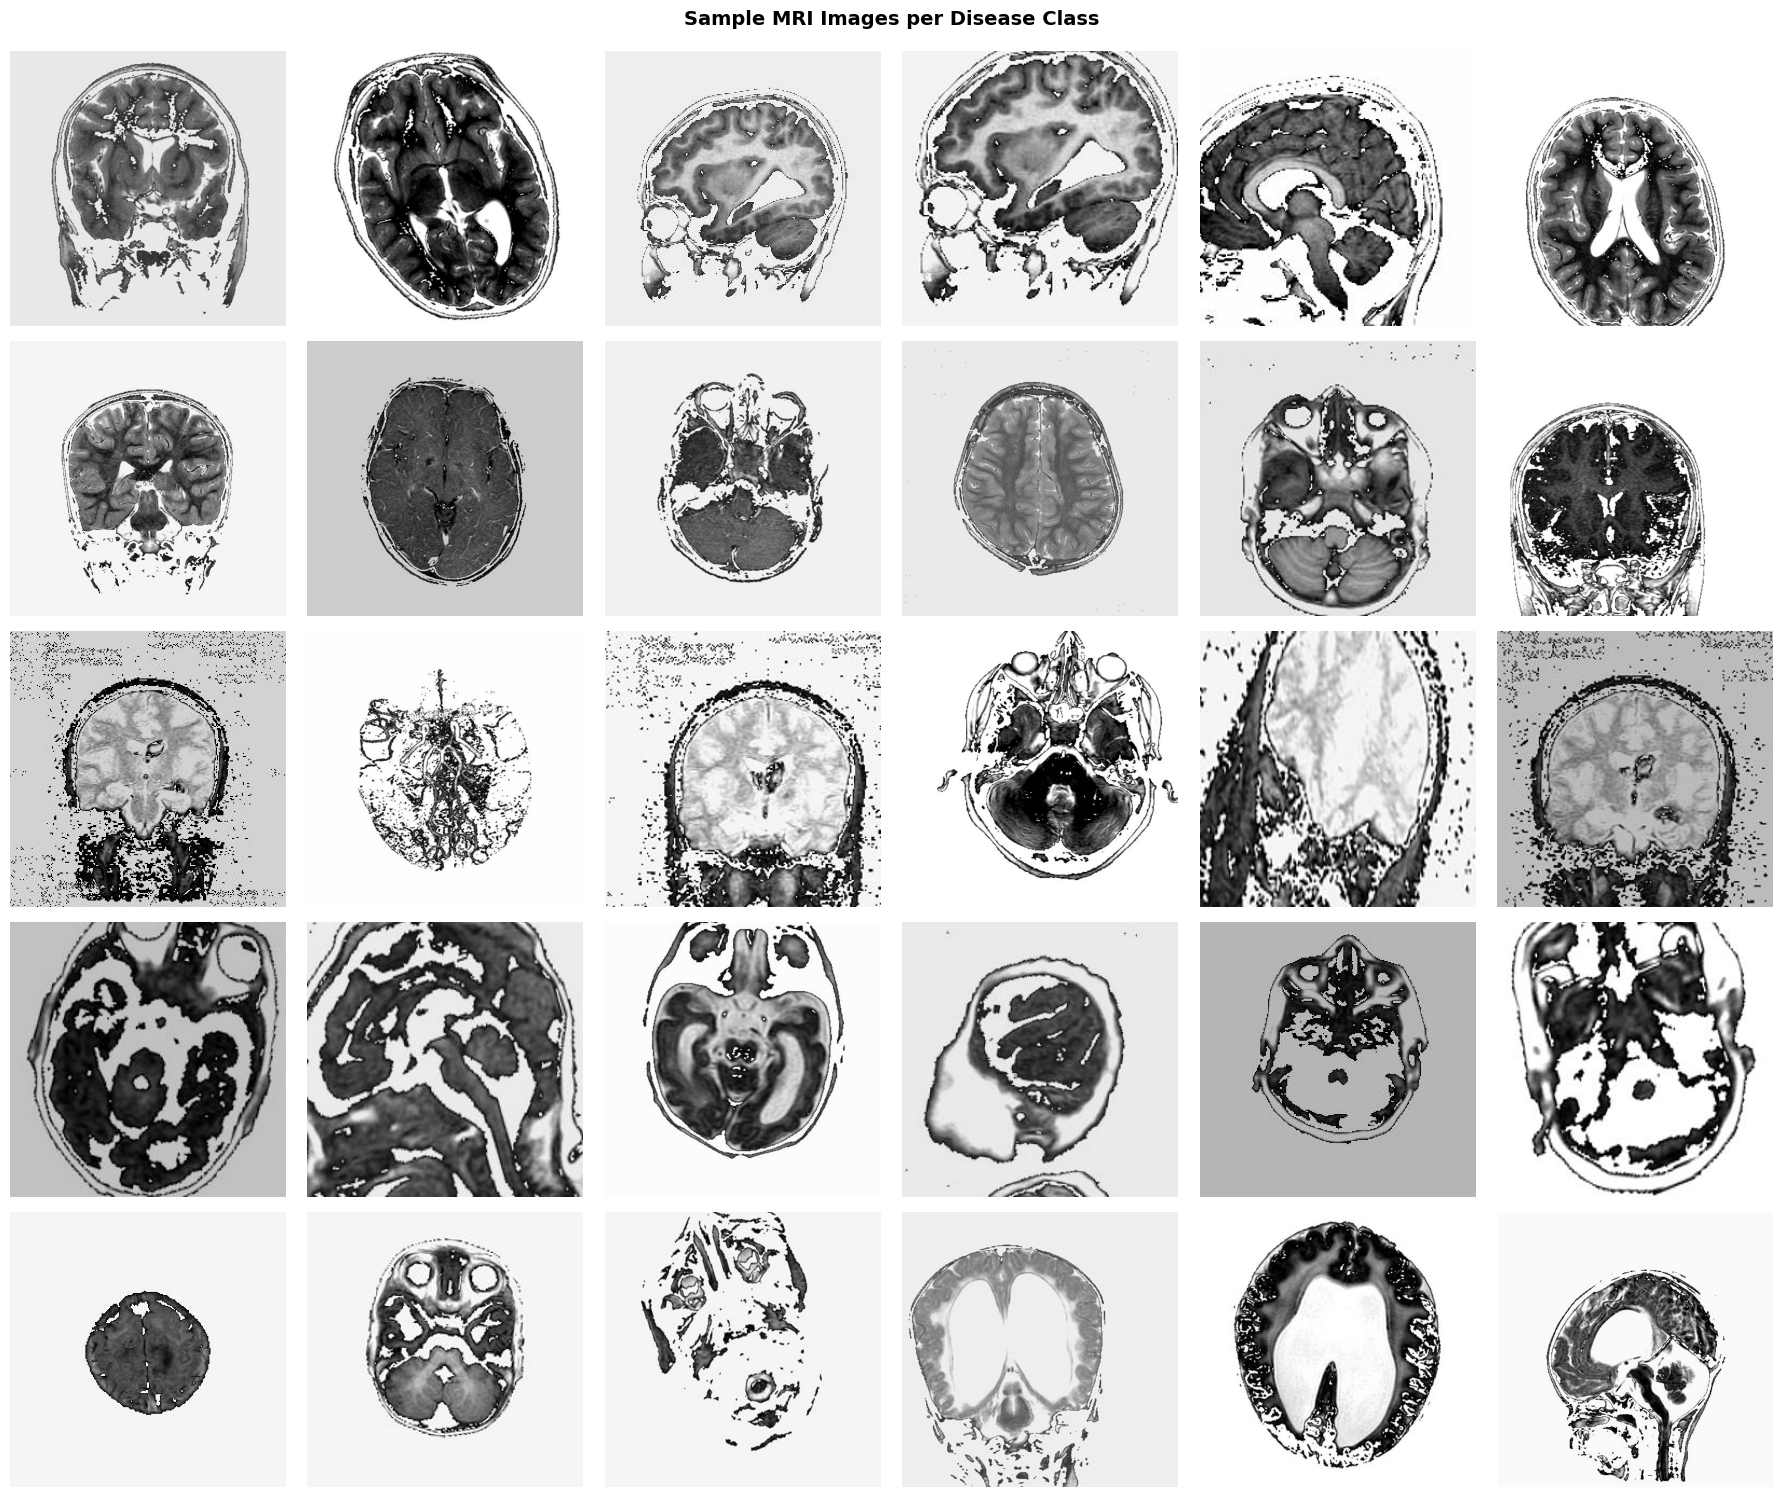

In [ ]:
# ---------------------------------------------------------
# Sample Grid Visualization
# ---------------------------------------------------------

def show_samples(n_per_class=4):
  # One subplot row per class, one column per requested sample
    fig, axes = plt.subplots(len(disease_classes), n_per_class,
                             figsize=(n_per_class*3, len(disease_classes)*3))
    train_path = os.path.join(DATASET_ROOT, 'train')

    for i, cls in enumerate(disease_classes):
        cls_path = os.path.join(train_path, cls)
        images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        # random.sample() draws WITHOUT replacement, so no duplicated tiles
        # min(...) protects against classes with fewer images than requested
        sampled = random.sample(images, min(n_per_class, len(images)))
        for j, img_name in enumerate(sampled):
            img_path = os.path.join(cls_path, img_name)
            img = Image.open(img_path)
            # cmap='gray' only when the file is single-channel ('L' mode)
            # RGB files must be shown without a colormap
            axes[i, j].imshow(img, cmap='gray' if img.mode == 'L' else None)
            axes[i, j].axis('off')
            if j == 0:
                '''CAVEAT: axis('off') above hides the whole axis, including its ylabel -
                so this class name is NOT rendered in the figure
                Use axes[i, j].set_title(cls) or ax.text(...) instead if the row labels are needed'''
                axes[i, j].set_ylabel(cls, fontsize=10, fontweight='bold',
                                      rotation=0, ha='right', va='center')

    plt.suptitle('Sample MRI Images per Disease Class', fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.savefig(UTILS_DIR / "sample_grid.png", dpi=150, bbox_inches='tight')
    plt.show()

show_samples(6)

> *Sample MRI images per disease class*
>
> A different random draw from *notebook 01*'s, since *`show_samples()`* runs before *`set_seed()`* \
> What appears in both grids is therefore a property of the dataset rather than of the draw:
>
> - **Mixed planes inside each class** (axial, coronal, sagittal), mixed head sizes, some non-brain sections
> - **Heavy window-levelling**, with saturated regions and posterised grey levels
> - **Rendering differs between classes**: the *moyamoya* row shows a distinctive background speckle in four of six tiles, *pachygyria* is posterised into near-binary black and white
>
> This matters slightly more here than in *notebook 01*: a frozen backbone can only read whatever cues exist, whereas a fine-tuned network optimises for them \
> It is a plausible part of why validation accuracy reaches exactly *1.0000* by *epoch 9*


## **4) Data transformation**

Same seed and same splits as *notebook 01* \
Three versions of the training split are used here:

- *`train_ds`* — augmentation ON, *`aug_factor=2`*: what the network actually trains on
- *`train_eval_ds`* — deterministic, *`aug_factor=1`*: used for anything that measures rather than trains
- *`fewshot_train_ds`* — augmentation ON but *`aug_factor=1`*, built in ***section 6***, so a subset of *n* indices really contains *n* distinct images


In [ ]:
# Global seed on notebook & dataset root
'''set_seed() seeds Python's random, NumPy and PyTorch in one call, so the augmentations,
the train/val sampling and the SVM tie-breaking are repeatable
Any change to SEED changes every stochastic result in the notebook
'''
SEED = 33
set_seed(SEED)

set_dataset_root(DATASET_ROOT)

Global dataset root set to: /content/drive/MyDrive/University/rare-neuro-mri/data/rare_neuro_mri_curated


In [ ]:
# Dataset initialization (Data Augmentation active only on train)
'''Three flavours of the training split are needed here:

  train_ds       -> augmentation ON, aug_factor=2. Used for the actual fine-tuning
  train_eval_ds  -> augmentation OFF, aug_factor=1. Used for feature extraction and for any
                     measurement: fixed images, one vector each
  fewshot_ds     -> augmentation ON, aug_factor=1 (built later)
                     Needed so a few-shot subset of n indices contains n DISTINCT images;
                     with aug_factor=2 the same image could be drawn twice and n_per_class would be a lie'''
train_ds, val_ds, test_ds, train_eval_ds = build_dataloaders(
    dataset_root=DATASET_ROOT,
    batch_size=32,
    img_size=224,
    aug_factor=2,
    seed=SEED,
    return_train_eval=True,
    classes=disease_classes
)

print(f"train (augmented, aug_factor=2): {len(train_ds)} samples "
      f"({train_ds.n_unique_samples} distinct images)")
print(f"train (clean, for extraction):   {len(train_eval_ds)} samples")
print(f"val: {len(val_ds)} | test: {len(test_ds)}")
print(f"class_to_idx: {train_eval_ds.class_to_idx}")


train (augmented, aug_factor=2): 2800 samples (1400 distinct images)
train (clean, for extraction):   1400 samples
val: 300 | test: 300
class_to_idx: {'fukuyama_muscular_dystrophy': 0, 'hallervorden_spatz_disease': 1, 'moyamoya_disease': 2, 'pachygyria_cerebellar_hypoplasia': 3, 'walker_warburg_syndrome': 4}


> *Dataset initialization*
>
> - *`train (augmented): 2800 samples (1400 distinct images)`* — one epoch is 2800 forward passes over
>   1400 distinct slices
> - *`val: 300 | test: 300`*, un-augmented
> - *`class_to_idx`* matches notebook 01 exactly; without that, the two models could not be compared and
>   the API would mislabel one of them


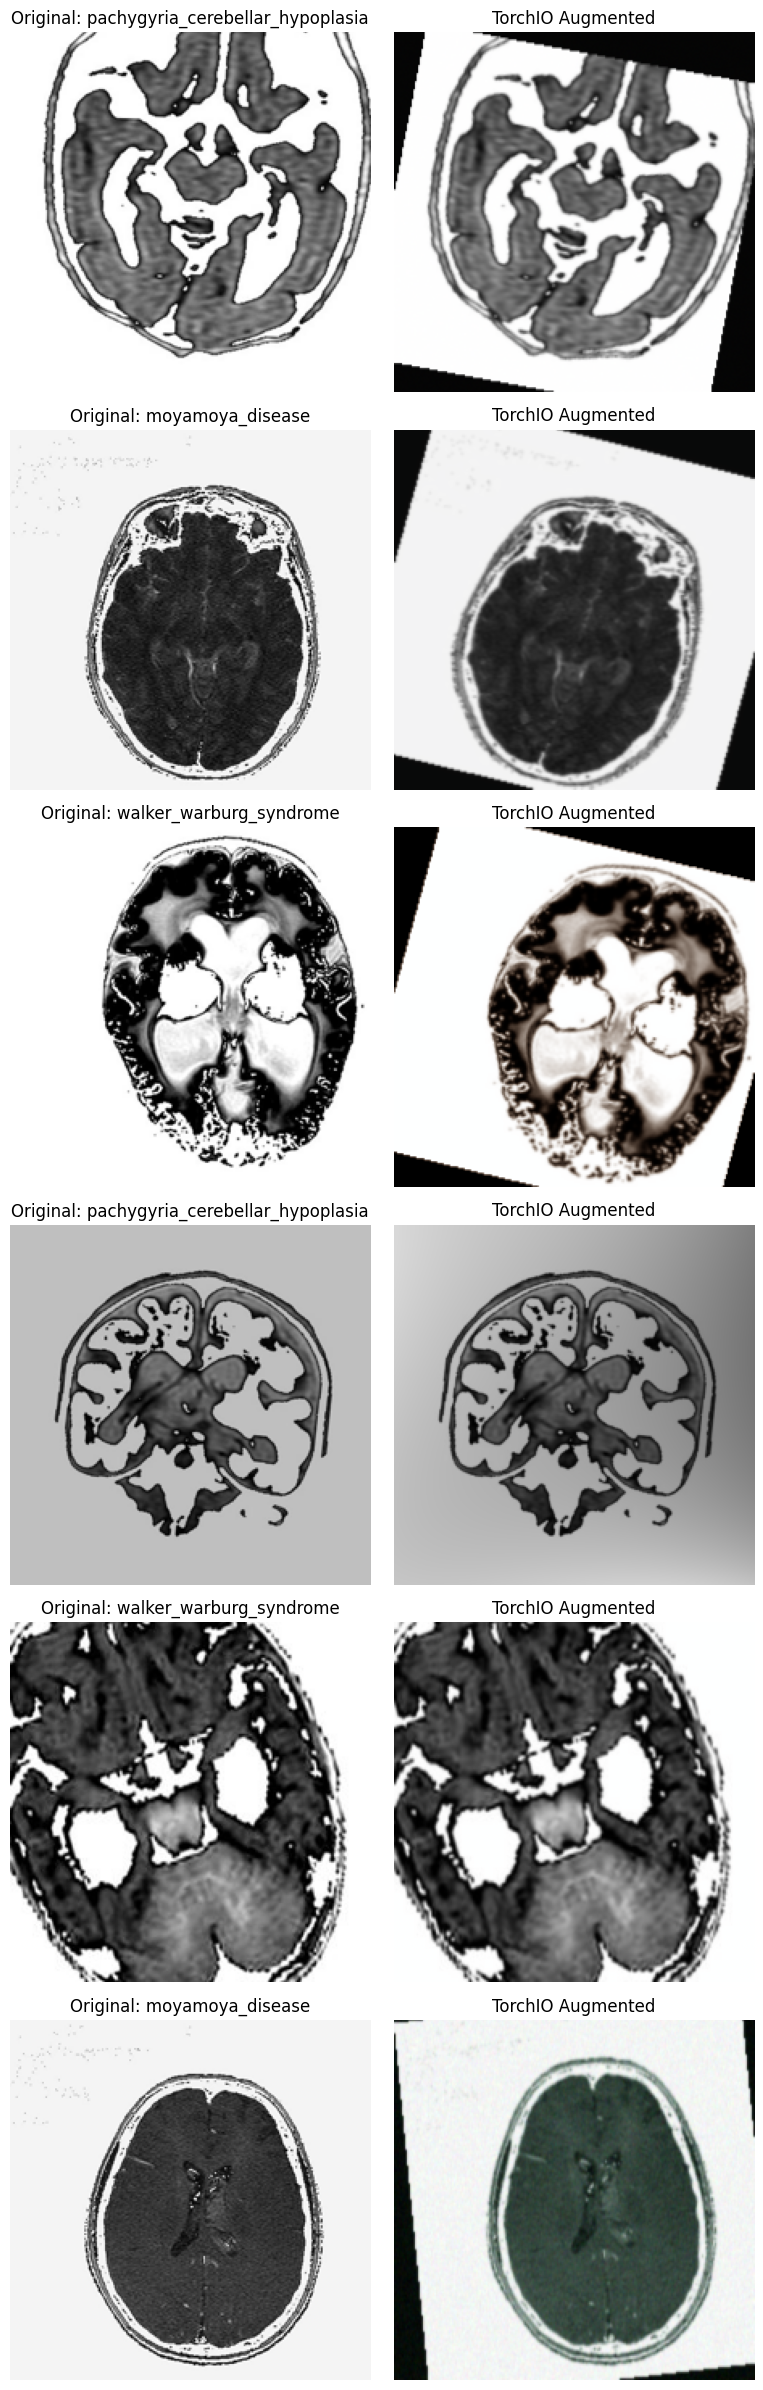

In [ ]:
# View some random examples to verify the quality of the transformations
''' original vs transformed pairs
Overly aggressive transforms (extreme rotation, intensity shifts that erase the lesion, flips that break left/right anatomy)
silently destroy the signal the model is supposed to learn
Same seed as above -> same samples every run'''

visualize_augmentations(train_ds, num_samples=6, seed=SEED)

> *Original vs TorchIO-augmented samples*
>
> Same seed as notebook 01, so the same figure — which is useful, because the augmentation inspected
> there is exactly the one the network trains on here
>
> - **Rotation** (rows 1, 2, 3, 6) with black zero-padded corners,
> - **bias field** (row 4) simulating coil inhomogeneity,
> - **gamma jitter** (rows 3, 5), and a colour cast in rows 3 and 6 from the per-channel bias field
> - Anatomy stays recognisable in every pair, and no horizontal flips are applied
>
> The zero-padded corners are the one artefact worth noting: they are a hard high-contrast edge present in no validation or test image \
> Padding with the border value instead of zero would remove it


In [ ]:
# Initialize the standard PyTorch DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

In [ ]:
# the number of distinct training images per class is needed to build the few-shot subsets
N_PER_CLASS_FULL = train_ds.n_unique_samples // len(disease_classes)
print(f"Distinct training images per class (full regime): {N_PER_CLASS_FULL}")

Distinct training images per class (full regime): 280


## **5) Lightweight end-to-end fine-tuning**

Only the last ConvNeXt stage (*`features[7]`*) and the new classification head are trainable;
*`freeze_backbone=True`* is the default in *`get_convnext_tiny_model`*

**Training setup:**
- **AdamW**, *`lr = 1e-4`*, *`weight_decay = 1e-2`*, given only the parameters with *`requires_grad=True`*
- **Cosine annealing** over the 15 epochs
- **Cross-entropy** loss, appropriate for a balanced 5-way problem
- **Checkpointing on the best validation loss** rather than accuracy — loss is the finer signal and
  saturates less easily


In [ ]:
# Model initialization with lightweight fine-tuning (only the last stage and the head unlocked)
model = get_convnext_tiny_model(
    num_classes=len(disease_classes),
    freeze_backbone=True,
    unfreeze_last_stage=True,
    device=DEVICE
)

trainable, total = count_trainable_parameters(model)
print(f"Trainable parameters: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

# Training hyperparameters
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-2


Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:02<00:00, 51.1MB/s]


Trainable parameters: 14,293,253 / 27,823,973 (51.4%)


>  *Model initialization*
>
> **`Trainable parameters: *14,293,253 / 27,823,973* (*51.4%*)`** confirms the freezing worked, but about the *51.4%*: \
> ConvNeXt-Tiny is back-loaded, and its last stage alone (three blocks at 768 channels) holds about half the network's weights \
> So *"last stage + head"* is a small number of **modules** but *half* the **parameters** — the **label** describes *which layers move*, not how many weights
>
> *14.3M* **trainable parameters** against *1400* **training images** is the regime where the augmentation and the weight decay are doing real work

In [ ]:
# Optimizer AdamW & Loss CrossEntropy
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

In [ ]:
# End-to-End Training Loop with Checkpointing on the best Validation Loss

best_val_loss = float('inf')
best_model_path = MODEL_DIR / "convnext_tiny_best.pth"

print("Starting ConvNeXt-Tiny End-to-End Fine-Tuning...\n")

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, _, _ = validate_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step()

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS:02d}] | "
          f"Train Loss: {train_loss:.4f} - Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} - Val Acc: {val_acc:.4f}")

    # Save the weights of the best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)

print(f"\nTraining completed! Best model saved to: {best_model_path}")

Starting ConvNeXt-Tiny End-to-End Fine-Tuning...

Epoch [01/15] | Train Loss: 0.6325 - Train Acc: 0.8071 | Val Loss: 0.1285 - Val Acc: 0.9633
Epoch [02/15] | Train Loss: 0.1072 - Train Acc: 0.9821 | Val Loss: 0.0287 - Val Acc: 0.9967
Epoch [03/15] | Train Loss: 0.0507 - Train Acc: 0.9904 | Val Loss: 0.0212 - Val Acc: 0.9933
Epoch [04/15] | Train Loss: 0.0370 - Train Acc: 0.9932 | Val Loss: 0.0171 - Val Acc: 0.9933
Epoch [05/15] | Train Loss: 0.0283 - Train Acc: 0.9943 | Val Loss: 0.0106 - Val Acc: 0.9967
Epoch [06/15] | Train Loss: 0.0185 - Train Acc: 0.9986 | Val Loss: 0.0057 - Val Acc: 0.9967
Epoch [07/15] | Train Loss: 0.0152 - Train Acc: 0.9982 | Val Loss: 0.0076 - Val Acc: 0.9967
Epoch [08/15] | Train Loss: 0.0153 - Train Acc: 0.9982 | Val Loss: 0.0132 - Val Acc: 0.9933
Epoch [09/15] | Train Loss: 0.0130 - Train Acc: 0.9982 | Val Loss: 0.0018 - Val Acc: 1.0000
Epoch [10/15] | Train Loss: 0.0109 - Train Acc: 0.9989 | Val Loss: 0.0021 - Val Acc: 1.0000
Epoch [11/15] | Train Loss: 0.

> *Fine-tuning loop — 15 epochs*
>
> Run of *15 epochs*:
> - **Convergence is fast**: *epoch 1* already reaches ***0.9633*** validation accuracy, and from *epoch 9* the
>   validation set is solved (*1.0000, 300/300*)
> - **Validation accuracy above training accuracy in epoch 1** is not an anomaly: \
>   training accuracy is *accumulated* during the epoch, on augmented images, with a model still improving; \
>   validation is measured afterwards on clean images \
>   The gap closes from *epoch 2*
> - **No overfitting signal**: train loss falls to *0.0080* and validation loss falls with it rather than
>   turning upward
>
> *Note:* from *epoch 9* onwards validation accuracy **no longer discriminates** between epochs, and \
> the remaining validation-loss differences (*0.0012* vs *0.0022*) are **noise on *300 images*** \
> The checkpoint is *epoch 11*, but any of *epochs 9–15* would have been an equally defensible choice


## **6) Test-set evaluation**

The best checkpoint is reloaded and scored **once** on the untouched test set \
*`validate_epoch`* returns the predictions together with the aligned true labels


In [ ]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

# Predictions and true labels on the pristine test set
test_loss, test_acc, y_test, test_preds = validate_epoch(model, test_loader, criterion, DEVICE)
test_macro_f1 = f1_score(y_test, test_preds, average='macro')

print(f"ConvNeXt-Tiny Final Test Accuracy: {test_acc:.4f} (Test Loss: {test_loss:.4f})")
print(f"ConvNeXt-Tiny Final Test Macro-F1: {test_macro_f1:.4f}")

ConvNeXt-Tiny Final Test Accuracy: 0.9967 (Test Loss: 0.0106)
ConvNeXt-Tiny Final Test Macro-F1: 0.9967


> *Test evaluation*
>
> - **Test accuracy *0.9967*** (*299/300*, **one error**), **macro-F1** *0.9967*, **test loss** *0.0106* \
>   The *95%* confidence interval is roughly **[98.1%, 99.9%]**
> - Against *notebook 01's 0.9867* this is a difference of **3 images out of 300** \
>   Both models are scored on exactly the **same test set**, so the honest reading is that the two strategies are **equivalent when all the data is available** \
>   — the difference is inside the noise and should not be interpreted as a win \
>   *The real difference between them shows up in the few-shot regime*
---
> *Note:* the **test loss** (*0.0106*) is about *nine times* the **best validation loss** (*0.0012*) while **accuracy** is barely *lower* \
> The **validation split** simply happens to be easier than the test split
> A reminder that a *single 300-image split* is a **noisy** instrument at this accuracy level


## **7) Embedding visualization**

*Notebook 01* projects the frozen ResNet-50 features with PCA and then with LDA \
The same request here is what the **fine-tuning did to the feature space** — but a different tool is needed.

**PCA and not LDA** \
In *notebook 01*, the backbone is frozen and never saw the labels, so LDA adds real information: it finds the discriminative directions that variance-maximising PCA hides \
In this case, if an unsupervised projection (PCA) already clearly separates the classes, it serves as direct confirmation that fine-tuning has successfully restructured the feature space \
LDA results are included to make the argument verifiable and to ensure a consistent comparison with *notebook 01*
- **Left panel (*Train*):** Reflects the data used during training, where cluster separation is partly due to memorization

- **Right panel (*Held-out*):** Provides concrete evidence of generalization; it demonstrates that class separation is real and remains valid even on unseen data

*Diagnostic only — nothing here feeds the model or the metrics*


Extracting embeddings: 100%|██████████| 10/10 [01:17<00:00,  7.76s/it]


Fine-tuned embeddings: train (1400, 768) | test (300, 768)
PC1 + PC2 explain 37.88% of the variance (PC1 19.80%, PC2 18.08%)
Separation (between/within scatter), PCA  train: 33.89 | test: 21.45
Separation (between/within scatter), LDA  train: 90.25 | test: 56.95
  -> LDA adds +166% over PCA on the held-out set
  -> the LDA test value is directly comparable with the one in notebook 01


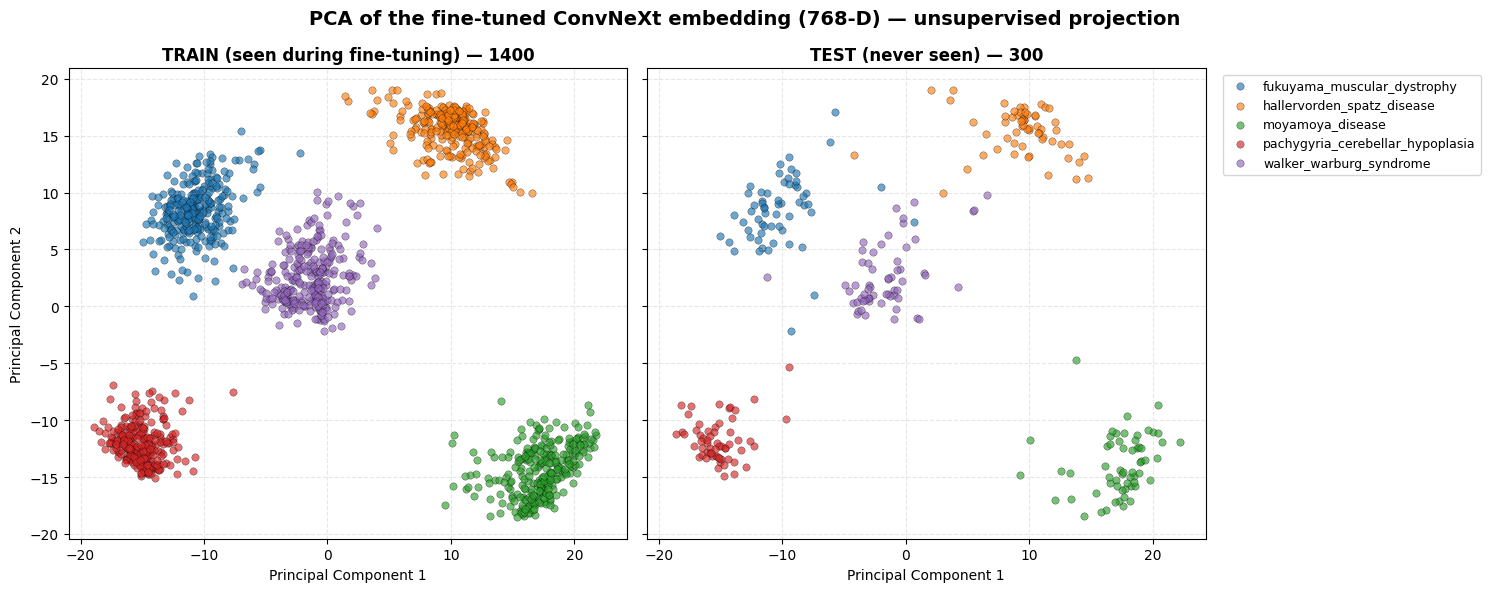

In [ ]:
# ---------------------------------------------------------
# Embedding visualization - what fine-tuning did to the feature space
# ---------------------------------------------------------
'''PCA of the fine-tuned 768-D embedding, fitted on train, plotted on train and test
PCA: the network was trained on these labels, so the embedding is already a supervised representation
 - an unsupervised projection shows what the fine-tuning itself achieved
The LDA figures are printed too'''

import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm


def extract_embeddings(model, dataset, device, batch_size=32):
    """768-D penultimate features: the final Linear is swapped for Identity, then restored"""
    model.eval()
    original_head = model.classifier[2]
    try:
        model.classifier[2] = nn.Identity()
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
        feats, labels = [], []
        with torch.no_grad():
            for images, y, _ in tqdm(loader, desc="Extracting embeddings"):
                feats.append(model(images.to(device)).cpu().numpy())
                labels.extend(y.numpy())
        return np.vstack(feats), np.array(labels)
    finally:
        model.classifier[2] = original_head          # restored even if interrupted


# train_eval_ds is the non-augmented training split: fixed images, one vector each
emb_train, emb_y_train = extract_embeddings(model, train_eval_ds, DEVICE)
emb_test, emb_y_test = extract_embeddings(model, test_ds, DEVICE)
print(f"Fine-tuned embeddings: train {emb_train.shape} | test {emb_test.shape}")

scaler_emb = StandardScaler().fit(emb_train)          # fitted on train only
pca_emb = PCA(n_components=2, random_state=SEED).fit(scaler_emb.transform(emb_train))
Ztr = pca_emb.transform(scaler_emb.transform(emb_train))
Zte = pca_emb.transform(scaler_emb.transform(emb_test))


def between_within(Z, y):
    """Between-class over within-class scatter: higher = better separated"""
    m = Z.mean(axis=0)
    b = sum(((Z[y == c].mean(axis=0) - m) ** 2).sum() * (y == c).sum() for c in np.unique(y))
    w = sum(((Z[y == c] - Z[y == c].mean(axis=0)) ** 2).sum() for c in np.unique(y))
    return b / max(w, 1e-12)      # guard: within-class scatter can vanish on tiny subsets


print(f"PC1 + PC2 explain {pca_emb.explained_variance_ratio_.sum():.2%} of the variance "
      f"(PC1 {pca_emb.explained_variance_ratio_[0]:.2%}, PC2 {pca_emb.explained_variance_ratio_[1]:.2%})")
pca_tr, pca_te = between_within(Ztr, emb_y_train), between_within(Zte, emb_y_test)
print(f"Separation (between/within scatter), PCA  train: {pca_tr:.2f} | test: {pca_te:.2f}")

# If supervised projectiion "almost nothing" on top, it means the
# embedding is already separable on its own and PCA is the right plot for this notebook
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
_p50 = PCA(n_components=50, random_state=SEED).fit(scaler_emb.transform(emb_train))
_lda = LinearDiscriminantAnalysis(n_components=2).fit(_p50.transform(scaler_emb.transform(emb_train)),
                                                     emb_y_train)
_Ltr = _lda.transform(_p50.transform(scaler_emb.transform(emb_train)))
_Lte = _lda.transform(_p50.transform(scaler_emb.transform(emb_test)))
lda_tr, lda_te = between_within(_Ltr, emb_y_train), between_within(_Lte, emb_y_test)
print(f"Separation (between/within scatter), LDA  train: {lda_tr:.2f} | test: {lda_te:.2f}")
print(f"  -> LDA adds {100*(lda_te/pca_te - 1):+.0f}% over PCA on the held-out set")
print(f"  -> the LDA test value is directly comparable with the one in notebook 01")

fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharex=True, sharey=True)
for ax, Z, y, title in [(axes[0], Ztr, emb_y_train, f"TRAIN (seen during fine-tuning) — {len(Ztr)}"),
                        (axes[1], Zte, emb_y_test, f"TEST (never seen) — {len(Zte)}")]:
    for idx, cls in enumerate(disease_classes):
        mask = (y == idx)
        ax.scatter(Z[mask, 0], Z[mask, 1], s=28, alpha=0.65,
                   edgecolors='black', linewidths=0.3, label=cls)
    ax.set_xlabel(f'Principal Component 1')
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')

axes[0].set_ylabel('Principal Component 2')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.suptitle('PCA of the fine-tuned ConvNeXt embedding (768-D) — unsupervised projection',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(UTILS_DIR / "pca_embedding_convnext.png", dpi=150, bbox_inches='tight')
plt.show()
plt.close()


> *PCA of the fine-tuned ConvNeXt embedding*
>
> The **1400 training** and **300 test** embeddings (768-D), standardised and projected onto the first 2 principal components
> - The first two components (PC1 + PC2) explain *37.88%* of the variance (compared to *10.86%* for the frozen backbone) \
>    The network has concentrated the representation, aligning the directions of maximum variance with the classes
> - **Five visibly distinct clusters** emerge in both the training and test sets  
>    Only *Walker-Warburg* and *Fukuyama* appear adjacent, while remaining distinct
>
> *Fine-Tuned vs Frozen*
>
> - **Unsupervised PCA outperforms LDA:** PCA alone on the model fine-tuned on test data (separation of *21.45*) exceeds the supervised LDA projection of the frozen model (*3.94*) by more than fivefold
> - When measured using LDA on held-out data, **class separability **increases from *3.94* (*notebook 01*) to *56.95*, **confirming** a representation that is approximately *14 times more discriminative*
>
> *Generalization and Fine-Tuning "Signature"*
>
> - **Train → Test Drop** (*-37%*): The separation index drops by *37%* on unseen data (PCA: *33.89 → 21.45*; LDA: *90.25 → 56.95*), compared to the negligible *-5.5%* drop seen with the frozen backbone
> - **Memorization under control:** This drop is the typical signature of training on labels \
>   There is some partial memorization of the training data, but the clusters in the test set remain widely separated, ensuring excellent generalization (consistent with the *99.67%* accuracy)
>
> *PCA & LDA*
>
> - **Structure beyond the first two PCs:** PC1 and PC2 capture *37.88%* of the variance, leaving part of the class structure in the subsequent components
> - **Added value of LDA:** Although PCA is sufficient to visually demonstrate separation, LDA leverages the remaining dimensions and increases separability on the test set by an additional *166%* (reaching *56.95*)
>
> *The embedding demonstrates that the classes are clearly distinguishable, but it does not allow one to isolate how much of this separation is due to actual anatomical features versus differences in preprocessing styles*

## **8) Few-shot robustness**

For a *fine-tuned network*, the shortcut used in *notebook 01* (shrink only the classifier's training set) could **not be used**: \
features extracted from a network already trained on the full training set carry that supervision into every *"few-shot"* point  

Was produced a flat curve at *~0.996* **accuracy** even with *10 examples per class*

For each subset size, and for each repetition:

1. draw a **class-balanced subset** of distinct training images;
2. **re-initialise ConvNeXt-Tiny from ImageNet weights**;
3. **fine-tune** on that subset only, with the same freezing scheme and hyperparameters;
4. **evaluate** on the untouched test set

**Cost:** *5* sizes x *3* runs = *15* complete fine-tuning runs, the longest cell in the project


In [ ]:
# ---------------------------------------------------------
# Few-shot: re-fine-tune from ImageNet on each subset
# ---------------------------------------------------------

FEWSHOT_SIZES = (10, 25, 50, 100, 200)
N_FEWSHOT_RUNS = 3      # repetitions per size -> the error bars
FEWSHOT_EPOCHS = 8      # epochs per run (subsets are small, they converge fast)

# Augmentation ON (it is training) but aug_factor=1, so a subset of n indices
# really contains n distinct images
fewshot_train_ds = build_fewshot_train_dataset(
    DATASET_ROOT, img_size=224, classes=disease_classes
)
print(f"Few-shot pool: {len(fewshot_train_ds)} distinct training images "
      f"({N_PER_CLASS_FULL} per class)\n")

fewshot_df = run_true_fewshot_finetuning(
    train_dataset=fewshot_train_ds,
    test_dataset=test_ds,
    class_names=disease_classes,
    device=DEVICE,
    fewshot_sizes=FEWSHOT_SIZES,
    n_runs=N_FEWSHOT_RUNS,
    epochs=FEWSHOT_EPOCHS,
    batch_size=32,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    freeze_backbone=True,
    unfreeze_last_stage=True,
    full_acc=test_acc,
    full_f1=test_macro_f1,
    n_full_per_class=N_PER_CLASS_FULL,
    seed=SEED
)

print("\nFew-shot results (true re-fine-tuning):")
print(fewshot_df.to_string(index=False))


Few-shot pool: 1400 distinct training images (280 per class)

  n_per_class=  10 | Acc 0.5600 +/- 0.0731 | Macro-F1 0.5575 +/- 0.0717
  n_per_class=  25 | Acc 0.7589 +/- 0.0350 | Macro-F1 0.7651 +/- 0.0316
  n_per_class=  50 | Acc 0.8844 +/- 0.0191 | Macro-F1 0.8850 +/- 0.0194
  n_per_class= 100 | Acc 0.9444 +/- 0.0103 | Macro-F1 0.9444 +/- 0.0103
  n_per_class= 200 | Acc 0.9856 +/- 0.0016 | Macro-F1 0.9856 +/- 0.0016

Few-shot results (true re-fine-tuning):
 n_per_class  acc_mean  acc_std  f1_mean   f1_std  n_runs
          10  0.560000 0.073080 0.557477 0.071691       3
          25  0.758889 0.034996 0.765113 0.031554       3
          50  0.884444 0.019116 0.885004 0.019406       3
         100  0.944444 0.010304 0.944414 0.010332       3
         200  0.985556 0.001571 0.985579 0.001612       3
         280  0.996667 0.000000 0.996666 0.000000       1


> *Few-shot results*
>
> | examples/class | ConvNeXt-Tiny (fine-tuned) | ResNet-50 + SVM (notebook 01) | difference |
> |---|---|---|---|
> | 10 | 0.5600 ± 0.0731 | **0.7160 ± 0.0110** | **+15.6 pp** for the frozen backbone |
> | 25 | 0.7589 ± 0.0350 | **0.8327 ± 0.0181** | +7.4 pp |
> | 50 | 0.8844 ± 0.0191 | **0.8947 ± 0.0081** | +1.0 pp |
> | 100 | 0.9444 ± 0.0103 | **0.9507 ± 0.0057** | +0.6 pp |
> | 200 | **0.9856 ± 0.0016** | 0.9793 ± 0.0025 | -0.6 pp |
> | 280 (full) | **0.9967** | 0.9867 | -1.0 pp |
>
> **The two strategies cross over at roughly 50-100 examples per class**
> - **Below the crossover the frozen backbone wins clearly** \
>   At *10 images* per class the gap is *15.6 points*, far outside the spread of either method \
>   Fine-tuning has *14.3M* trainable parameters and *50* total images to constrain them; \
>   the SVM fits a hyperplane in a fixed feature space and degrades gently
> - **Above the crossover fine-tuning wins**, but by less than one point
> - **For rare diseases** — a handful of annotated cases per condition — the frozen pipeline is
>   therefore the better choice, and it is also far cheaper to train
>
> **Stability and Relevance for Rare Diseases** \
> - **High variability with limited data:** With *10* examples per class, the standard deviation of fine-tuning is nearly seven times higher (*0.0731 vs. 0.0110*) \
>    Performance depends heavily on the specific sample selected (fluctuations of ±7 points)
> - For **rare diseases** (where few annotated cases are available), the frozen-backbone approach is the best choice: it ensures *greater accuracy*, *high stability*, and significantly *lower computational costs*
>
---
> *Execution Notes:*
> - **Imbalance in optimization steps:** Fixing the number of epochs (*FEWSHOT_EPOCHS = 8*) means that smaller subsets perform fewer updates (*16 steps* for the *10-sho*t setting versus *256* for the *200-shot* setting) \
>    Consequently, the few-shot fine-tuned model is slightly **under-trained**; the observed performance gap favoring the SVM should therefore be considered an upper bound
>
> *The results (derived from 15 complete training runs) are based on a verified restoration of artifacts*

## **9) Metrics evaluation and artifact saving**

*`evaluate_and_save_all`* prints the metrics, saves the confusion matrix and the per-class chart, and
writes the results JSON, the artifacts pickle and the model weights to the *convnext* folders

*The few-shot curve is plotted separately*

 EVALUATION RESULTS: CONVNEXT_TINY_FINETUNED
Test Accuracy:     0.9967
Test Macro-F1:     0.9967
Test Weighted-F1:  0.9967

Detailed Classification Report:
                                  precision    recall  f1-score   support

     fukuyama_muscular_dystrophy     0.9836    1.0000    0.9917        60
      hallervorden_spatz_disease     1.0000    0.9833    0.9916        60
                moyamoya_disease     1.0000    1.0000    1.0000        60
pachygyria_cerebellar_hypoplasia     1.0000    1.0000    1.0000        60
         walker_warburg_syndrome     1.0000    1.0000    1.0000        60

                        accuracy                         0.9967       300
                       macro avg     0.9967    0.9967    0.9967       300
                    weighted avg     0.9967    0.9967    0.9967       300



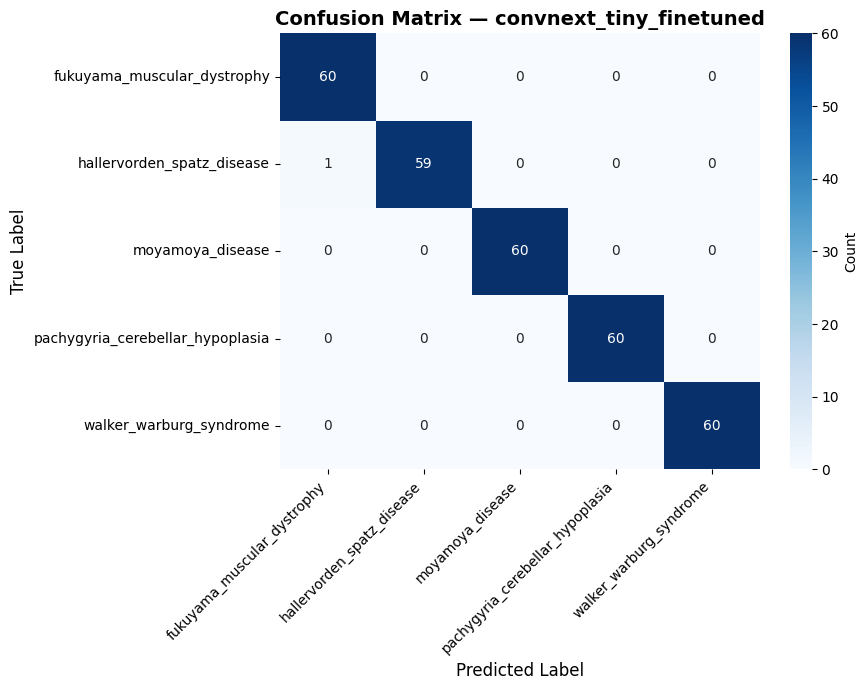

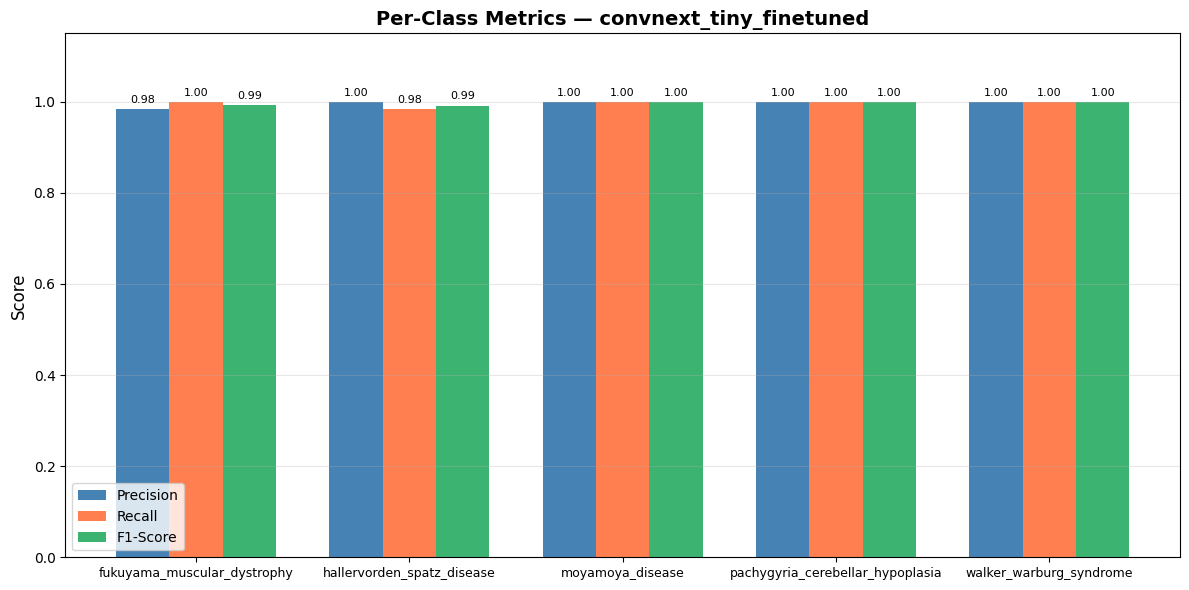


 Output saved:
  - Graphs saved in: /content/drive/MyDrive/University/rare-neuro-mri/convnext utils
  - Artifacts and Weights saved in: /content/drive/MyDrive/University/rare-neuro-mri/convnext models

Few-shot protocol: ConvNeXt-Tiny re-initialised from ImageNet and re-fine-tuned on each subset (3 runs x 8 epochs)


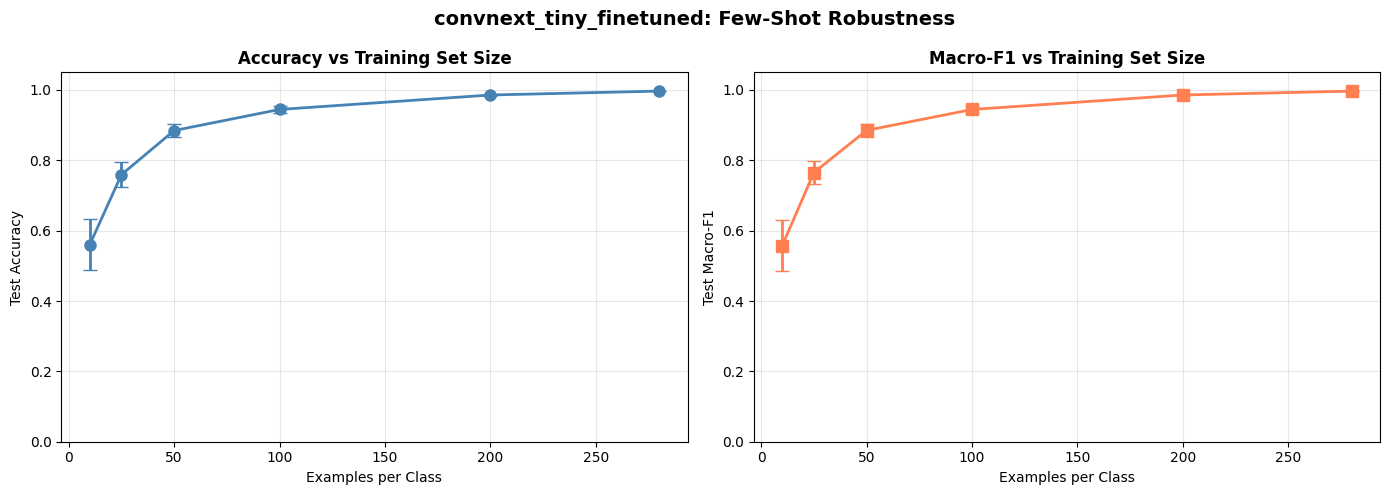

 n_per_class  acc_mean  acc_std  f1_mean   f1_std  n_runs
          10  0.560000 0.073080 0.557477 0.071691       3
          25  0.758889 0.034996 0.765113 0.031554       3
          50  0.884444 0.019116 0.885004 0.019406       3
         100  0.944444 0.010304 0.944414 0.010332       3
         200  0.985556 0.001571 0.985579 0.001612       3
         280  0.996667 0.000000 0.996666 0.000000       1

Few-shot table saved to /content/drive/MyDrive/University/rare-neuro-mri/convnext models/convnext_tiny_finetuned_fewshot.csv


In [ ]:
from metrics import plot_fewshot_results

FEWSHOT_PROTOCOL = (f"ConvNeXt-Tiny re-initialised from ImageNet and re-fine-tuned on each "
                    f"subset ({N_FEWSHOT_RUNS} runs x {FEWSHOT_EPOCHS} epochs)")

artifacts = {
    'model_architecture': 'convnext_tiny',
    'class_names': disease_classes,          # the head predicts integer indices only
    'class_to_idx': train_eval_ds.class_to_idx,
    'img_size': 224,
    'freeze_backbone': True,
    'unfreeze_last_stage': True,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'best_val_loss': float(best_val_loss),
    'calibrated_probabilities': False,       # softmax scores, not Platt-calibrated
    'fewshot_df': fewshot_df,
    'fewshot_protocol': FEWSHOT_PROTOCOL,
    'fewshot_sizes': list(FEWSHOT_SIZES),
    'fewshot_n_runs': N_FEWSHOT_RUNS,
    'fewshot_epochs': FEWSHOT_EPOCHS,
}

# confusion matrix + per-class chart + JSON + artifacts + weights
evaluate_and_save_all(
    y_true=y_test,
    y_pred=test_preds,
    class_names=disease_classes,
    utils_dir=UTILS_DIR,
    model_dir=MODEL_DIR,
    model_name="convnext_tiny_finetuned",
    artifacts_to_save=artifacts,
    torch_model_to_save=model,
    seed=SEED
)

# few-shot curve, plotted from the DataFrame produced by the re-fine-tuning study
print(f"\nFew-shot protocol: {FEWSHOT_PROTOCOL}")
plot_fewshot_results(
    fewshot_df,
    model_name="convnext_tiny_finetuned",
    save_path=UTILS_DIR / "fewshot_convnext_tiny_finetuned.png"
)
print(fewshot_df.to_string(index=False))

# evaluate_and_save_all() sets 'fewshot_results' to None in the pickle (it computed no
# curve of its own), so the numbers are persisted here in a readable form as well
fewshot_df.to_csv(MODEL_DIR / "convnext_tiny_finetuned_fewshot.csv", index=False)
print(f"\nFew-shot table saved to {MODEL_DIR / 'convnext_tiny_finetuned_fewshot.csv'}")

> ***Confusion matrix*** \
> Four classes out of five are perfect (60/60) \
> The single error in the whole test set is one *hallervorden–spatz* slice predicted as *fukuyama*;
> **the same confusion appeared in notebook 01**, where it was one of the four ResNet errors \
> Two different architectures failing on the same image is weak but real evidence that the image itself is atypical; \
> with a single error, opening that file and looking at it is feasible
---
> ***Per-class metrics***
>
> | class | precision | recall | F1 |
> |---|---|---|---|
> | fukuyama_muscular_dystrophy | 0.984 | 1.000 | 0.992 |
> | hallervorden_spatz_disease | 1.000 | 0.983 | 0.992 |
> | moyamoya_disease | 1.000 | 1.000 | 1.000 |
> | pachygyria_cerebellar_hypoplasia | 1.000 | 1.000 | 1.000 |
> | walker_warburg_syndrome | 1.000 | 1.000 | 1.000 |
>
> The mirror image of the single error: *fukuyama* loses precision (it received the stray prediction), *hallervorden–spatz* loses recall \
> Three classes at a flat *1.000* mean the error rate is below roughly 1/60; \
> at that point the test set has no resolution left to distinguish a very good model from a perfect one, and the per-class table stops being informative
---
> ***Few-shot curve*** \
> The figure, shape-wise it is the same kind of logarithmic curve as notebook 01's, but the two differ:
>
> - **The left-hand end is much lower** \
>   ConvNeXt starts at *0.560* where the SVM starts at *0.716*, and its error bar at n = 10 is visibly the largest on the plot; \
>   the only point where the whiskers are clearly wider than the marker
> - **The right-hand end is slightly higher**, ending at 0.9967 against 0.9867
> - So the ConvNeXt curve is **steeper**: it needs more data to get going, and rewards it slightly better once it has it
>
> The last point (*280* examples per class) is the full-data model appended as a reference: \
> a single run, so its zero-width error bar is not a measured variance, and it was trained for 15 epochs with
> validation checkpointing rather than the 8 fixed epochs of the few-shot runs \
> It is a reference marker rather than a strictly comparable point on the same curve


## **10) Deployment check: model selection, confidence and rejection**

This section prepares the artifacts the API will load \
It answers three questions that the accuracy figure alone cannot:
- *which of the two models should be deployed?*
- *does its reported confidence mean anything?*
- *can it refuse an input it was never meant to classify?*


#### → ConvNeXt-Tiny is the deployed model
The project compares two strategies, and the API can serve only one. The choice is **not** settled by the test accuracy (almost equivalent), but was evaluated by other components.

- **Irrelevance of the low-data regime:** The SVM's strong advantage in low-data contexts does not apply to the API, which is trained on all *1,400* available images
- **Explainability (Grad-CAM):** ConvNeXt natively supports Grad-CAM (API requirement) \
   With SVM, it is not possible to calculate output gradients with respect to the input
- **Representation quality:** Class separability on unseen data (LDA) is approximately *14* times higher for ConvNeXt (*56.95 vs. 3.94*), ensuring more predictable behavior on edge cases
- **Infrastructure robustness:** ConvNeXt requires a single weights file (`*state_dict*`) \
   The SVM pipeline requires a backbone, a scaler, and scikit-learn *`.pkl`* files, which are prone to version compatibility issues


***Model calibration***

- **Handling out-of-distribution inputs:** The model operates on five closed classes, yet the production API may receive images showing other pathologies, different modalities, or healthy subjects \
   A rejection threshold was established based on the 5th percentile of confidence scores from the validation set, setting a false positive/rejection rate of *5%* a priori

- **Efficiency compared to alternatives:** Compared to using *Mahalanobis distance* in feature space (which offered identical performance but required a *768x768* matrix and additional data processing steps), the confidence-based threshold proved to be the simpler and more effective choice

In [ ]:
# ---------------------------------------------------------
# Deployment check: is the confidence usable, and can the model refuse an input?
# ---------------------------------------------------------
'''The head has five outputs and a softmax, so ANY image - a healthy scan, a chest X-ray, a
photograph - gets confidently assigned to one of the five diseases
The API needs a way to say "none of these", and it needs to know whether the reported confidence means anything

To address those requests, were used the validation logits:
  ECE       how far the claimed confidence sits from the observed accuracy
  threshold the 5th percentile of validation confidence, i.e. the value that refuses 5% of
            genuine inputs by construction - no out-of-distribution data required'''

import pickle
import numpy as np
import torch
from torch.utils.data import DataLoader

REJECT_PERCENTILE = 5      # -> ~5% of genuine inputs refused

def get_logits(dataset, desc):
    model.eval()
    out, labels = [], []
    with torch.no_grad():
        for images, y, _ in tqdm(DataLoader(dataset, batch_size=32, num_workers=2), desc=desc):
            out.append(model(images.to(DEVICE)).cpu())
            labels.extend(y.numpy())
    return torch.cat(out), np.array(labels)


lg_val, y_v = get_logits(val_ds, "val")
lg_test, y_t = get_logits(test_ds, "test")
p_val = torch.softmax(lg_val, 1).numpy()
p_test = torch.softmax(lg_test, 1).numpy()

# --- 1. is the confidence honest? ---
conf, pred = p_test.max(1), p_test.argmax(1)
acc = (pred == y_t).mean()
ece = sum(m.mean() * abs((pred == y_t)[m].mean() - conf[m].mean())
          for lo, hi in zip(np.arange(0, 1, .1), np.arange(.1, 1.1, .1))
          if (m := (conf > lo) & (conf <= hi)).sum())

print(f"\nTest accuracy {acc:.4f} | mean confidence {conf.mean():.4f} | ECE {ece:.4f}")
print("  ECE is the mean gap between claimed confidence and observed accuracy;")
print("  below ~0.02 the softmax can be reported as-is, no calibration needed.")

# --- 2. rejection threshold ---
CONF_THRESHOLD = float(np.percentile(p_val.max(1), REJECT_PERCENTILE))
kept = conf >= CONF_THRESHOLD
print(f"\nThreshold {CONF_THRESHOLD:.4f} ({REJECT_PERCENTILE}th percentile of validation confidence)")
print(f"  refused on validation {(p_val.max(1) < CONF_THRESHOLD).mean():.1%} | "
      f"on test {(~kept).mean():.1%}")
print(f"  accuracy on the {kept.sum()} accepted test images: {(pred[kept] == y_t[kept]).mean():.4f}")

# --- 3. does it actually fire on something that is not an MRI? ---
noise = torch.rand(24, 3, 224, 224)
noise = (noise - torch.tensor([.485, .456, .406]).view(1, 3, 1, 1)) / \
        torch.tensor([.229, .224, .225]).view(1, 3, 1, 1)
with torch.no_grad():
    c_noise = torch.softmax(model(noise.to(DEVICE)), 1).max(1).values.cpu().numpy()
print(f"\nRandom noise: mean confidence {c_noise.mean():.4f}, "
      f"refused {(c_noise < CONF_THRESHOLD).mean():.0%}")
print("  Noise is the EASY case. A healthy brain MRI is in-domain visually and would score much")
print("  higher; this cannot be measured without real out-of-distribution data.")

# --- save what the API needs ---
with open(MODEL_DIR / "convnext_tiny_finetuned_artifacts.pkl", 'rb') as f:
    artifacts = pickle.load(f)
artifacts.update({'confidence_threshold': CONF_THRESHOLD, 'ece': float(ece),
                  'reject_percentile': REJECT_PERCENTILE})
with open(MODEL_DIR / "convnext_tiny_finetuned_artifacts.pkl", 'wb') as f:
    pickle.dump(artifacts, f)

# Slim bundle for the container: plain Python only, so the image needs neither pandas
# (the full pickle holds a DataFrame) nor scikit-learn
with open(MODEL_DIR / "convnext_tiny_deploy.pkl", 'wb') as f:
    pickle.dump({'class_names': list(disease_classes), 'img_size': 224,
                 'confidence_threshold': CONF_THRESHOLD,
                 'test_accuracy': float(acc), 'ece': float(ece)}, f)

print(f"\nSaved convnext_tiny_deploy.pkl")

test: 100%|██████████| 10/10 [00:03<00:00,  3.15it/s]



Test accuracy 0.9967 | mean confidence 0.9968 | ECE 0.0048
  ECE is the mean gap between claimed confidence and observed accuracy;
  below ~0.02 the softmax can be reported as-is, no calibration needed.

Threshold 0.9990 (5th percentile of validation confidence)
  refused on validation 5.0% | on test 6.7%
  accuracy on the 280 accepted test images: 1.0000

Random noise: mean confidence 0.3494, refused 100%
  Noise is the EASY case. A healthy brain MRI is in-domain visually and would score much
  higher; this cannot be measured without real out-of-distribution data.

Saved convnext_tiny_deploy.pkl


> *Deployment check: **calibration and rejection***
>
> *Calibration* — no correction required
>
> | | value |
> |---|---|
> | test accuracy | *0.9967* |
> | mean confidence | *0.9968* |
> | **ECE** | **0.0048** |
>
> - **High numerical reliability:** The average confidence (*99.68%*) aligns with the observed accuracy (99.67%), with an ECE of just *0.0048* (well below the *0.05-0.15* range typical of uncalibrated convolutional networks) \
>   Softmax is used directly without modification
>
> - **Inapplicability of temperature scaling:** Since the validation set was solved without errors (*300/300*), temperature optimization mathematically collapses to zero \
>   Calibration was verified

> *Statistical note:* With *299* out of *300* correct predictions in the test set, the vast majority of data points fall into the **highest confidence bin**, making ECE a less discriminating metric

> *Rejection Mechanism Operation*
>
> - **High threshold (*0.9990*):** Reflects the model's high level of certainty regarding known data and is set at the *5th* percentile of the validation set
>
> - **Impact on the test set:** The API rejects *5.0%* of images in the validation set (by design) and *6.7%* in the test set (*20 images*)
>
> - **Accuracy on accepted data (100%):** Accuracy is perfect across the *280* accepted images \
>   The single error in the test set was detected and discarded by the filter, demonstrating the desired safety behavior (albeit based on a single error case)
>
> *Out-of-Distribution (OOD) Behavior and Clinical Limitations*
>
> - **Rejection of random noise:** Noise inputs yield an average confidence of *0.3494* and are rejected 100% of the time, confirming the basic operation of the abstention mechanism
>
> - **Limitations regarding clinical OOD data:** Noise serves as a simple test \
>    Images visually similar to training data (*scans from healthy patients or those with pathologies other than the five studied*) share the same anatomy and modality, and could potentially mislead the Softmax layer into reporting high confidence
>





---

## **11) Comparison with notebook 01**

| | ResNet-50 + SVM | ConvNeXt-Tiny fine-tuned |
|---|---|---|
| Test accuracy (full data) | 0.9867 (296/300) | **0.9967** (299/300) |
| Accuracy at 10 examples/class | **0.716 ± 0.011** | 0.560 ± 0.073 |
| Crossover | — | ~50–100 examples/class |
| Embedding separability (LDA, test) | 3.94 | **56.95** |
| Probabilities | Platt-calibrated | temperature-scaled (section 10) |
| Grad-CAM | not possible | **available** |
| Trainable parameters | 0 | 14.3M |

***Which model is better to use?***

- **With the full dataset the two strategies are equivalent:** \
   3 images of difference on 300, well inside the noise
- Few shot tests: they diverge in favour of the *simpler* method \
  At 10 labelled examples per class the frozen backbone is *15.6* points more accurate and about *7x* more stable

*Classical feature extraction results as a better engineering choice where there are few annotated cases per conditions*

***Which one goes into the API: ConvNeXt***\
In the deployment scenario, the model is trained on all *1,400* images, thereby negating the SVM's advantage in many-shot contexts

ConvNeXt is preferred due to:

- **Grad-CAM support:** A fundamental requirement for the explainability API (impossible with SVM, as it lies outside the autograd graph)

- **Embedding quality:** *~14* times higher class separability (*56.95 vs. 3.94*), ensuring greater stability in edge cases

- **Infrastructure robustness:** It requires a single weights file (`*.pth*`), avoiding the fragility associated with `*.pkl*` files and their dependency on specific library versions


---

## **12) *OPTIONAL* - Augmented MRI images generation**

*Seed and number of generated image can be CHANGED*

It could be useful to **test the API** by using augmented version of
the original datasets' images

In [ ]:
# ---------------------------- settings -------------------------------
OUT_DIR    = BASE_DIR / "api_test_images"   # where the JPGs are written
N_IMAGES   = 100                            # how many to generate
GEN_SEED   = 5296                           # MUST differ from the training seed (33)
SPLIT      = 'test'                         # 'test' recommended: never used for training
# ---------------------------------------------------------------------

import csv
import numpy as np
from pathlib import Path
from PIL import Image
from dataset import MRIDataset, TorchIOMRITransform, set_seed, IMAGENET_MEAN, IMAGENET_STD

assert GEN_SEED != 33, "GEN_SEED must differ from the training seed (33)"

OUT_DIR = Path(OUT_DIR)
OUT_DIR.mkdir(parents=True, exist_ok=True)
set_seed(GEN_SEED)

# augmentation ON (is_train=True) but reading from the chosen split
ds = MRIDataset(DATASET_ROOT, SPLIT,
                TorchIOMRITransform(img_size=224, is_train=True),
                augmentation_factor=1)
classes, labels = ds.classes, ds.get_labels()

# class-balanced choice of source images
rng = np.random.RandomState(GEN_SEED)
per_class, chosen = N_IMAGES // len(classes), []
for c in range(len(classes)):
    idx = np.where(labels == c)[0]
    chosen.extend(rng.choice(idx, per_class, replace=per_class > len(idx)))
while len(chosen) < N_IMAGES:
    chosen.append(int(rng.choice(len(ds))))
rng.shuffle(chosen)

mean = np.array(IMAGENET_MEAN).reshape(3, 1, 1)
std  = np.array(IMAGENET_STD).reshape(3, 1, 1)
rows = []

for i, idx in enumerate(chosen):
    idx = int(idx)
    tensor, label, cls = ds[idx]        # TorchIO draw happens here

    # undo the ImageNet normalisation to recover a viewable image
    arr = np.clip(tensor.numpy() * std + mean, 0, 1).transpose(1, 2, 0)
    Image.fromarray((arr * 255).astype(np.uint8)).save(
        OUT_DIR / f"{i:03d}_{cls}.jpg", quality=95)

    # the true class is in the filename, so predictions can be verified
    rows.append({'filename': f"{i:03d}_{cls}.jpg", 'true_class': cls, 'label': label,
                 'source_file': Path(ds.samples[idx][0]).name, 'split': SPLIT, 'seed': GEN_SEED})

with open(OUT_DIR / "manifest.csv", 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)

print(f"{len(rows)} images written to {OUT_DIR}")
print(f"  split: {SPLIT} | seed: {GEN_SEED} (training used 33)")
print(f"  per class: { {c: sum(r['true_class'] == c for r in rows) for c in classes} }")

100 images written to /content/drive/MyDrive/University/rare-neuro-mri/api_test_images
  split: test | seed: 5296 (training used 33)
  per class: {'fukuyama_muscular_dystrophy': 20, 'hallervorden_spatz_disease': 20, 'moyamoya_disease': 20, 'pachygyria_cerebellar_hypoplasia': 20, 'walker_warburg_syndrome': 20}


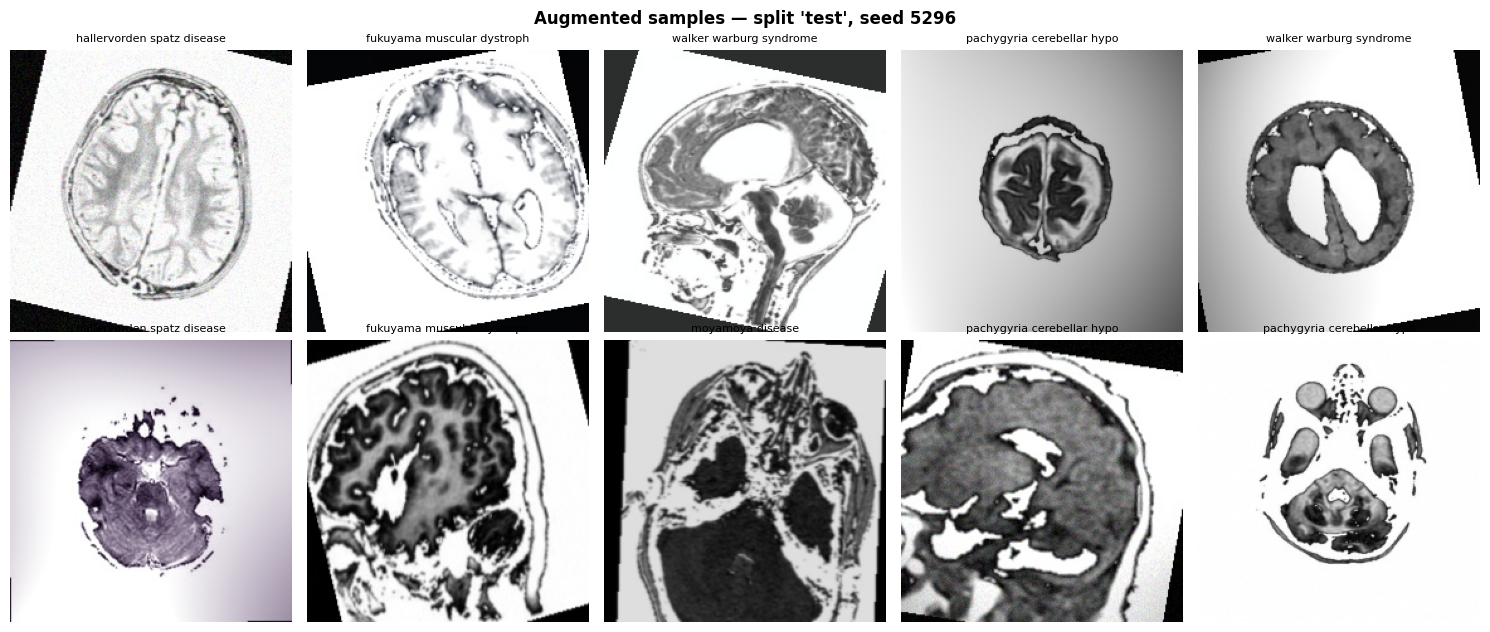

In [12]:
# quick visual check
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 5, figsize=(15, 6.4))
for ax, r in zip(axes.ravel(), rows[:10]):
    ax.imshow(Image.open(OUT_DIR / r['filename'])); ax.axis('off')
    ax.set_title(r['true_class'].replace('_', ' ')[:26], fontsize=8)
plt.suptitle(f"Augmented samples — split '{SPLIT}', seed {GEN_SEED}", fontweight='bold')
plt.tight_layout(); plt.show()